# Direction C - So sánh gen phụ và biến thể lõi 

Tập trung vào câu hỏi:

> Với cùng bài toán dự đoán kháng kháng sinh, nhóm đặc trưng nào mạnh hơn: **gen phụ** hay **biến thể lõi**?

## Ý tưởng Direction C

- **Gen phụ**: các gen không xuất hiện ở tất cả các mẫu. Nhóm này có thể chứa gen kháng thuốc, plasmid, transposase hoặc vùng di truyền di động.
- **Biến thể lõi**: các biến đổi nhỏ trong phần gen chung giữa các mẫu. Nhóm này phản ánh thay đổi trong phần hệ gen ổn định hơn.
- **Kết hợp**: dùng cả gen phụ và biến thể lõi để xem hai nguồn tín hiệu có bổ sung cho nhau không.

## Pipeline

```text
GitHub data của bài báo
→ đọc nhãn kháng/không kháng cho 5 thuốc
→ đọc ma trận gen phụ
→ đọc ma trận biến thể lõi
→ chia train/test nhiều lần
→ chọn đặc trưng chỉ trên train
→ train mô hình
→ so sánh gen phụ vs biến thể lõi vs kết hợp
```

## 0. Cấu hình


In [1]:
# =========================
# Cấu hình chính
# =========================

N_REPEATS = 10
TEST_SIZE = 0.20
RANDOM_SEED_BASE = 42

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

# Số đặc trưng chọn từ mỗi nguồn.
# Với combined, notebook sẽ chọn K_FEATURES từ ma trận kết hợp.
K_FEATURES = 200

# Giới hạn số feature theo phương sai để tránh quá nặng RAM.
# Nếu Colab RAM yếu, giảm các số này.
MAX_ACCESSORY_FEATURES_FOR_PREFILTER = 15000
MAX_CORE_SNP_FEATURES_FOR_PREFILTER = 15000

BASE_DIR = "/content/salmonella_direction_C"
REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"

print("Cấu hình:")
print("N_REPEATS =", N_REPEATS)
print("K_FEATURES =", K_FEATURES)
print("BASE_DIR =", BASE_DIR)

Cấu hình:
N_REPEATS = 10
K_FEATURES = 200
BASE_DIR = /content/salmonella_direction_C


## 1. Cài thư viện

In [2]:
import os
import sys
import subprocess
from pathlib import Path

BASE_DIR = Path(BASE_DIR)
BASE_DIR.mkdir(parents=True, exist_ok=True)

REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"

if not REPO_DIR.exists():
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    print("Repo đã tồn tại:", REPO_DIR)

# Công cụ giải nén .rar
!apt-get update -qq
!apt-get install -y -qq unrar p7zip-full

# Thư mục output
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo:", REPO_DIR)
print("Output:", OUTPUT_DIR)

Cloning into '/content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 79 (delta 33), reused 54 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.95 MiB | 10.09 MiB/s, done.
Resolving deltas: 100% (33/33), done.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Repo: /content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella
Output: /content/salmonella_direction_C/outputs


## 2. Import thư viện

In [3]:
import re
import json
import shutil
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("Import xong.")

Import xong.


## 3. Đọc bảng, giải nén và chuẩn hóa ma trận

In [4]:
def list_files(root, suffixes=None, max_items=50):
    root = Path(root)
    if not root.exists():
        return []
    files = []
    for p in root.rglob("*"):
        if p.is_file():
            if suffixes is None or p.suffix.lower() in suffixes:
                files.append(p)
    files = sorted(files, key=lambda x: x.stat().st_size if x.exists() else 0, reverse=True)
    return files[:max_items]


def read_table_flexible(path):
    path = Path(path)
    suffix = path.suffix.lower()
    print("Đang đọc:", path, "| size:", round(path.stat().st_size / 1024 / 1024, 2), "MB")
    if suffix == ".csv":
        try:
            return pd.read_csv(path, low_memory=False)
        except Exception:
            return pd.read_csv(path, sep=None, engine="python")
    if suffix in [".tsv", ".txt"]:
        return pd.read_csv(path, sep=None, engine="python", low_memory=False)
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    raise ValueError(f"Không hỗ trợ định dạng: {path}")


def extract_archive(archive_path, out_dir):
    archive_path = Path(archive_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if not archive_path.exists():
        print("Không thấy archive:", archive_path)
        return False

    print("\nGiải nén:", archive_path)
    print("Ra thư mục:", out_dir)

    code1 = os.system(f'unrar x -o+ "{archive_path}" "{out_dir}/"')
    if code1 == 0 and len(list(out_dir.rglob("*"))) > 0:
        print("Giải nén bằng unrar thành công.")
        return True

    code2 = os.system(f'7z x -y "{archive_path}" -o"{out_dir}"')
    if code2 == 0 and len(list(out_dir.rglob("*"))) > 0:
        print("Giải nén bằng 7z thành công.")
        return True

    print("CẢNH BÁO: giải nén thất bại hoặc không có file.")
    return False


def find_largest_table(root):
    root = Path(root)
    candidates = list_files(root, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"], max_items=30)
    if not candidates:
        return None
    print(f"\nCác bảng tìm thấy trong {root}:")
    for p in candidates[:10]:
        print(" -", p.name, round(p.stat().st_size / 1024 / 1024, 2), "MB")
    return candidates[0]


def find_and_extract_named_archive(search_root, name_keywords, out_dir):
    search_root = Path(search_root)
    archives = []
    for suffix in ["*.rar", "*.zip", "*.7z"]:
        archives.extend(search_root.rglob(suffix))

    def score_archive(p):
        s = str(p).lower()
        score = 0
        for kw in name_keywords:
            if kw.lower() in s:
                score += 1
        return score

    archives = sorted(archives, key=lambda p: (score_archive(p), p.stat().st_size), reverse=True)
    print("\nArchive candidates:")
    for p in archives[:10]:
        print(" -", p, "| score", score_archive(p), "| size", round(p.stat().st_size/1024/1024, 2), "MB")

    for p in archives:
        if score_archive(p) > 0:
            ok = extract_archive(p, out_dir)
            if ok:
                return p
    return None


def maybe_download_raw(url, out_path):
    out_path = Path(out_path)
    if out_path.exists() and out_path.stat().st_size > 1000:
        print("Đã có:", out_path)
        return out_path
    print("Tải:", url)
    os.system(f'wget -O "{out_path}" "{url}"')
    if out_path.exists():
        print("Kích thước:", round(out_path.stat().st_size/1024/1024, 2), "MB")
    return out_path


def normalize_sample_index(df, labels_index, name):
    # Cố gắng gán index mẫu. Nếu không có mã mẫu nhưng số dòng bằng số nhãn, gán theo thứ tự nhãn.
    df = df.copy()

    possible_id_cols = []
    for col in df.columns[:10]:
        low = str(col).lower()
        if any(k in low for k in ["sample", "accession", "biosample", "id", "strain", "name"]):
            possible_id_cols.append(col)

    for col in possible_id_cols:
        vals = df[col].astype(str)
        overlap = len(set(vals) & set(labels_index.astype(str)))
        if overlap > 0:
            print(f"{name}: dùng cột {col} làm mã mẫu, khớp {overlap} mẫu.")
            df.index = vals
            df = df.drop(columns=[col])
            return df

    if df.shape[0] == len(labels_index):
        print(f"{name}: không thấy cột mã mẫu rõ ràng, nhưng số dòng = {len(labels_index)}. Gán index theo thứ tự nhãn.")
        df.index = labels_index
        return df

    print(f"CẢNH BÁO {name}: số dòng {df.shape[0]} không bằng số nhãn {len(labels_index)} và không tìm thấy mã mẫu khớp.")
    return df



def orient_feature_matrix_by_labels(df, labels_index, name):
    """
    Đưa ma trận về dạng: rows = samples, columns = features.

    Một số file trong bộ này được lưu ngược chiều:
    - accessory gene: thường là 1167 hàng mẫu × nhiều cột gene.
    - core SNP: thường có thể là nhiều hàng SNP × 1167 cột mẫu.

    Nếu số cột bằng số mẫu nhãn, hàm sẽ tự transpose.
    Nếu số hàng bằng số mẫu nhãn, hàm sẽ gán index mẫu theo thứ tự.
    """
    df = df.copy()
    labels_index = pd.Index(labels_index)
    n_labels = len(labels_index)

    # Bỏ các cột index rác nếu có.
    unnamed_cols = [col for col in df.columns if str(col).lower().startswith("unnamed")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    # Nếu có dạng feature_id + 1167 cột mẫu, lấy cột đầu làm tên feature rồi transpose.
    if df.shape[1] == n_labels + 1:
        first_col = df.columns[0]
        first_values = df[first_col].astype(str)
        numeric_ratio = pd.to_numeric(first_values, errors="coerce").notna().mean()
        if numeric_ratio < 0.95:
            print(f"{name}: phát hiện dạng feature_id + {n_labels} cột mẫu. Dùng cột đầu làm tên feature rồi transpose.")
            feature_ids = first_values.values
            tmp = df.drop(columns=[first_col])
            tmp = tmp.T
            tmp.index = labels_index
            tmp.columns = make_unique([str(x) for x in feature_ids], prefix=f"{name}_feature")
            return tmp

    # Nếu số hàng bằng số nhãn: đây đã là rows=samples.
    if df.shape[0] == n_labels:
        return normalize_sample_index(df, labels_index, name)

    # Nếu số cột bằng số nhãn: đang bị ngược chiều, cần transpose.
    if df.shape[1] == n_labels:
        print(f"{name}: phát hiện ma trận bị ngược chiều ({df.shape[0]} feature × {df.shape[1]} mẫu). Transpose về {n_labels} mẫu × feature.")
        old_index = df.index
        tmp = df.T
        tmp.index = labels_index
        # Nếu index cũ có vẻ là tên feature thì giữ, nếu không tự tạo tên.
        if old_index.is_unique and not isinstance(old_index, pd.RangeIndex):
            tmp.columns = make_unique([str(x) for x in old_index], prefix=f"{name}_feature")
        else:
            tmp.columns = [f"{name}_feature_{i}" for i in range(tmp.shape[1])]
        return tmp

    # Nếu không nhận ra, quay về hàm cũ để cố gắng tìm cột mẫu.
    print(f"CẢNH BÁO {name}: không nhận ra chiều ma trận rõ ràng, thử normalize_sample_index. shape={df.shape}, n_labels={n_labels}")
    return normalize_sample_index(df, labels_index, name)


def make_unique(names, prefix="feature"):
    """Tạo tên cột unique để tránh lỗi khi concat/select."""
    seen = {}
    out = []
    for i, name in enumerate(names):
        if name is None or str(name).strip() == "" or str(name).lower() == "nan":
            name = f"{prefix}_{i}"
        name = str(name)
        if name not in seen:
            seen[name] = 0
            out.append(name)
        else:
            seen[name] += 1
            out.append(f"{name}__dup{seen[name]}")
    return out


def encode_feature_matrix(df, name, max_features_for_prefilter=None):
    print(f"\nMã hóa ma trận {name}, raw shape =", df.shape)
    X = df.copy()

    drop_cols = []
    for col in X.columns:
        low = str(col).lower()
        if low.startswith("unnamed") or low in ["index"]:
            drop_cols.append(col)
    if drop_cols:
        X = X.drop(columns=drop_cols)

    nucleotide_map = {
        "A": 0, "C": 1, "G": 2, "T": 3,
        "a": 0, "c": 1, "g": 2, "t": 3,
        "N": -1, "n": -1, "-": -1, ".": -1, "?": -1,
    }

    for col in list(X.columns):
        if X[col].dtype == "object":
            s = X[col]
            nunique = s.nunique(dropna=True)

            numeric = pd.to_numeric(s, errors="coerce")
            if numeric.notna().mean() > 0.95:
                X[col] = numeric
                continue

            if nunique <= 10:
                mapped = s.map(nucleotide_map)
                if mapped.notna().mean() > 0.5:
                    X[col] = mapped.fillna(-1)
                else:
                    codes, _ = pd.factorize(s.astype(str), sort=True)
                    X[col] = codes
                continue

            X = X.drop(columns=[col])

    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.dropna(axis=1, how="all")
    X = X.fillna(0)

    nunique = X.nunique(dropna=False)
    keep = nunique[nunique > 1].index
    X = X[keep]

    print(f"{name}: sau numeric + bỏ cột hằng số =", X.shape)

    if max_features_for_prefilter is not None and X.shape[1] > max_features_for_prefilter:
        print(f"{name}: quá nhiều feature ({X.shape[1]}). Giữ top {max_features_for_prefilter} theo phương sai.")
        variances = X.var(axis=0)
        top_cols = variances.sort_values(ascending=False).head(max_features_for_prefilter).index
        X = X[top_cols]
        print(f"{name}: sau prefilter =", X.shape)

    return X


def select_k_chi2_train_only(X_train, y_train, X_test, k):
    # Chi-square yêu cầu feature không âm. Dùng MinMaxScaler fit trên train.
    k = min(k, X_train.shape[1])

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    selector = SelectKBest(score_func=chi2, k=k)
    X_train_sel = selector.fit_transform(X_train_scaled, y_train)
    X_test_sel = selector.transform(X_test_scaled)

    selected_cols = np.array(X_train.columns)[selector.get_support()]
    return X_train_sel, X_test_sel, selected_cols

## 4. Đọc nhãn kháng/không kháng

In [5]:
def load_label_for_drug(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    label_path = drug_dir / f"{drug}_label.csv"
    if not label_path.exists():
        raise FileNotFoundError(f"Không thấy label file: {label_path}")

    y_df = pd.read_csv(label_path)
    if y_df.shape[1] == 1:
        y = y_df.iloc[:, 0]
    else:
        possible = [c for c in y_df.columns if "label" in str(c).lower() or drug.lower() in str(c).lower()]
        y = y_df[possible[0]] if possible else y_df.iloc[:, -1]

    y = y.replace({
        "S": 0, "I": 0, "R": 1,
        "s": 0, "i": 0, "r": 1,
        "Susceptible": 0, "Intermediate": 0, "Resistant": 1,
    }).astype(int)

    y.index = [f"sample_{i}" for i in range(len(y))]
    return y


label_by_drug = {drug: load_label_for_drug(drug) for drug in DRUGS}

data_stats = []
for drug, y in label_by_drug.items():
    data_stats.append({
        "drug": drug,
        "n_samples": len(y),
        "n_resistant": int(y.sum()),
        "n_non_resistant": int((y == 0).sum()),
        "resistant_rate": float(y.mean()),
    })

data_stats_df = pd.DataFrame(data_stats)
display(data_stats_df)
data_stats_df.to_csv(OUTPUT_DIR / "direction_C_dataset_label_stats.csv", index=False)

,drug,n_samples,n_resistant,n_non_resistant,resistant_rate
0,AMP,1167,199,968,0.170523
1,AUG,1167,139,1028,0.119109
2,AXO,1167,71,1096,0.060840
3,CHL,1167,126,1041,0.107969
4,FOX,1167,71,1096,0.060840


## 5. Đọc ma trận gen phụ

In [6]:
EXTRACT_DIR = BASE_DIR / "extracted"
ACCESSORY_EXTRACT_DIR = EXTRACT_DIR / "accessory_gene"
CORE_SNP_EXTRACT_DIR = EXTRACT_DIR / "core_snp"
ACCESSORY_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
CORE_SNP_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

accessory_table = find_largest_table(ACCESSORY_EXTRACT_DIR)
if accessory_table is None:
    archive = find_and_extract_named_archive(REPO_DIR, ["accessory", "gene", "existence", "roary"], ACCESSORY_EXTRACT_DIR)
    accessory_table = find_largest_table(ACCESSORY_EXTRACT_DIR)

if accessory_table is None:
    raw_url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella/raw/main/results/Roary/accessory%20gene%20existence%20matrix.rar"
    archive_path = BASE_DIR / "accessory_gene_existence_matrix.rar"
    maybe_download_raw(raw_url, archive_path)
    extract_archive(archive_path, ACCESSORY_EXTRACT_DIR)
    accessory_table = find_largest_table(ACCESSORY_EXTRACT_DIR)

if accessory_table is None:
    raise FileNotFoundError("Không tìm được bảng ma trận gen phụ.")

accessory_raw = read_table_flexible(accessory_table)

labels_index = label_by_drug["AMP"].index
accessory_raw = orient_feature_matrix_by_labels(accessory_raw, labels_index, "accessory_gene")
X_accessory = encode_feature_matrix(
    accessory_raw,
    "accessory_gene",
    max_features_for_prefilter=MAX_ACCESSORY_FEATURES_FOR_PREFILTER
)

if X_accessory.shape[0] == len(labels_index):
    X_accessory.index = labels_index

print("X_accessory shape:", X_accessory.shape)
display(X_accessory.head())


Archive candidates:
 - /content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar | score 4 | size 0.44 MB
 - /content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/gene_presence_absence.rar | score 2 | size 0.4 MB
 - /content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella/results/MAFFT/core SNP matrix.rar | score 0 | size 1.87 MB

Giải nén: /content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar
Ra thư mục: /content/salmonella_direction_C/extracted/accessory_gene
Giải nén bằng unrar thành công.

Các bảng tìm thấy trong /content/salmonella_direction_C/extracted/accessory_gene:
 - accessory gene existence matrix.csv 40.59 MB
Đang đọc: /content/salmonella_direction_C/extracted/accessory_gene/accessory gene existence matrix.csv | size: 40.59 MB
accessory_gene: không thấy cột 

,ccdB,J7C65_003890,DK588_19620,JWS55_001066,D6I09_15270,ccdA,E6U56_20795,C2K47_20970,C2488_20440,DRI21_24680,D5T90_22780,CE329_23785,LQN83_003980,group_3281,KFT09_004614,GV134_13825,CBU32_20390,BWQ25_23105,C2485_21565,HX982_004100,GPA43_004124,repA,C2F11_21375,CEW36_24625,KLW05_004653,GIT43_19180,spvA,traT,psiB,traX,EJ247_21195,GSC00_003820,BWQ25_23435,group_5508,CW931_22560,tap,traF,trbE,LL873_004076,LKA01_003597,CHI38_20865,trbI,CKP58_21310,spvB,traR,IRQ96_003806,MPS34_003964,traQ,C8859_19160,group_4097,CHU49_20955,trbC,traW,trbB,traG,traV,group_1699,sopE2,traU,traN,...,GSC02_003939,group_14053,GSC17_004628,CHU14_16720,GOQ46_004968,GSC70_004734,GSC70_004761,rbn,GSD57_002573,GSD57_002563,GVB94_004749,GSD57_002564,GVB94_004783,GVB94_004089,GSD57_002568,GVB94_005006,E3I96_08020,GOO02_004940,GOO02_004971,GOO02_004985,group_19145,H8V14_003085,narI,emrA,group_10929,GSD50_004889,GSD50_004895,trmL,GSD50_004457,GSD50_004900,group_10615,GSD50_004896,GSD50_004897,GRX98_004916,bsmA,HBY45_003073,GRX98_004821,GRX98_004919,GRX98_004817,GRX98_004908,GRX98_004918,GRX98_004906,GOQ53_003250,GOQ53_003799,GOQ53_003245,GOQ53_003246,GOQ53_003298,GOQ53_002525,GOQ53_002526,GOQ53_002527,GOQ53_002528,GOQ53_002529,GOQ53_002530,GOQ53_002531,GOQ53_003297,GOQ53_003296,GOQ53_003295,GOQ53_003294,GOQ53_003289,GOQ53_003287
sample_0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sample_1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sample_2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sample_3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sample_4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 6. Đọc ma trận biến thể lõi

In [7]:
core_snp_table = find_largest_table(CORE_SNP_EXTRACT_DIR)
if core_snp_table is None:
    archive = find_and_extract_named_archive(REPO_DIR, ["core", "snp"], CORE_SNP_EXTRACT_DIR)
    core_snp_table = find_largest_table(CORE_SNP_EXTRACT_DIR)

if core_snp_table is None:
    raw_url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella/raw/main/results/MAFFT/coreSNP.rar"
    archive_path = BASE_DIR / "coreSNP.rar"
    maybe_download_raw(raw_url, archive_path)
    extract_archive(archive_path, CORE_SNP_EXTRACT_DIR)
    core_snp_table = find_largest_table(CORE_SNP_EXTRACT_DIR)

if core_snp_table is None:
    print("CẢNH BÁO: Không tìm được bảng core SNP.")
    print("Direction C sẽ vẫn chạy phần accessory_gene, nhưng không thể so sánh đầy đủ với core SNP.")
    X_core_snp = None
else:
    core_snp_raw = read_table_flexible(core_snp_table)

    # FIX quan trọng:
    # File coreSNP của bộ này thường được lưu dạng SNP × sample,
    # tức là khoảng 126087 hàng SNP và 1167 cột mẫu.
    # Notebook cũ hiểu nhầm 126087 hàng là sample nên lỗi khi align với y.
    # Hàm này sẽ tự transpose nếu thấy số cột = số mẫu nhãn.
    core_snp_oriented = orient_feature_matrix_by_labels(core_snp_raw, labels_index, "core_snp")

    X_core_snp = encode_feature_matrix(
        core_snp_oriented,
        "core_snp",
        max_features_for_prefilter=MAX_CORE_SNP_FEATURES_FOR_PREFILTER
    )

    if X_core_snp.shape[0] == len(labels_index):
        X_core_snp.index = labels_index

    print("X_core_snp shape:", X_core_snp.shape)
    display(X_core_snp.head())


Archive candidates:
 - /content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella/results/MAFFT/core SNP matrix.rar | score 2 | size 1.87 MB
 - /content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar | score 0 | size 0.44 MB
 - /content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/gene_presence_absence.rar | score 0 | size 0.4 MB

Giải nén: /content/salmonella_direction_C/Antimicrobial-resistance-prediction-in-Salmonella/results/MAFFT/core SNP matrix.rar
Ra thư mục: /content/salmonella_direction_C/extracted/core_snp
Giải nén bằng unrar thành công.

Các bảng tìm thấy trong /content/salmonella_direction_C/extracted/core_snp:
 - coreSNP.csv 281.73 MB
Đang đọc: /content/salmonella_direction_C/extracted/core_snp/coreSNP.csv | size: 281.73 MB
core_snp: phát hiện ma trận bị ngược chiều (126087 feature × 1167 mẫu). Transpose về 1167 mẫu × feature.

Mã hó

,core_snp_feature_13249,core_snp_feature_13257,core_snp_feature_13255,core_snp_feature_13254,core_snp_feature_13289,core_snp_feature_13292,core_snp_feature_13280,core_snp_feature_13279,core_snp_feature_13260,core_snp_feature_8386,core_snp_feature_8391,core_snp_feature_8385,core_snp_feature_38631,core_snp_feature_12605,core_snp_feature_33209,core_snp_feature_33208,core_snp_feature_33318,core_snp_feature_33326,core_snp_feature_33323,core_snp_feature_33322,core_snp_feature_33324,core_snp_feature_33331,core_snp_feature_33321,core_snp_feature_96040,core_snp_feature_58376,core_snp_feature_125561,core_snp_feature_13284,core_snp_feature_13281,core_snp_feature_13265,core_snp_feature_13308,core_snp_feature_13259,core_snp_feature_13272,core_snp_feature_13274,core_snp_feature_13285,core_snp_feature_13268,core_snp_feature_13300,core_snp_feature_13310,core_snp_feature_13295,core_snp_feature_13294,core_snp_feature_13270,core_snp_feature_118700,core_snp_feature_63986,core_snp_feature_85694,core_snp_feature_81039,core_snp_feature_27986,core_snp_feature_13283,core_snp_feature_13288,core_snp_feature_21741,core_snp_feature_21740,core_snp_feature_8384,core_snp_feature_70025,core_snp_feature_8383,core_snp_feature_11149,core_snp_feature_124860,core_snp_feature_117989,core_snp_feature_42516,core_snp_feature_115331,core_snp_feature_74089,core_snp_feature_2914,core_snp_feature_2917,...,core_snp_feature_73970,core_snp_feature_111086,core_snp_feature_123418,core_snp_feature_48670,core_snp_feature_120171,core_snp_feature_75504,core_snp_feature_33363,core_snp_feature_120917,core_snp_feature_43441,core_snp_feature_45649,core_snp_feature_90934,core_snp_feature_120426,core_snp_feature_19931,core_snp_feature_2845,core_snp_feature_4524,core_snp_feature_35197,core_snp_feature_114914,core_snp_feature_65441,core_snp_feature_10816,core_snp_feature_104490,core_snp_feature_113089,core_snp_feature_5059,core_snp_feature_52033,core_snp_feature_14792,core_snp_feature_71057,core_snp_feature_91118,core_snp_feature_71045,core_snp_feature_54518,core_snp_feature_26628,core_snp_feature_117833,core_snp_feature_123992,core_snp_feature_5684,core_snp_feature_26630,core_snp_feature_117725,core_snp_feature_18567,core_snp_feature_115822,core_snp_feature_18598,core_snp_feature_16016,core_snp_feature_47875,core_snp_feature_70537,core_snp_feature_29158,core_snp_feature_71926,core_snp_feature_9267,core_snp_feature_47690,core_snp_feature_71908,core_snp_feature_15415,core_snp_feature_123987,core_snp_feature_71984,core_snp_feature_75140,core_snp_feature_75065,core_snp_feature_53368,core_snp_feature_24666,core_snp_feature_13324,core_snp_feature_125048,core_snp_feature_90311,core_snp_feature_113455,core_snp_feature_2797,core_snp_feature_56083,core_snp_feature_4389,core_snp_feature_28463
sample_0,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,0,0,0,0,0,0,0,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,1,4,4,1,3,3,0,0,3,4,3,1,4,1,4,4,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,4,2,2,3,4,4,2,2,4,2,4,2,2,2,4,4,4,2,4,4,3,4,4,4,4,4,2,2,4,2,4,3,2,2,4,4,2,2,4,2,4,4,3,4,3
sample_1,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,0,0,0,0,0,0,0,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,1,4,4,1,3,3,0,0,3,4,3,1,4,1,4,4,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,4,2,2,3,4,4,2,2,4,2,4,2,2,2,4,4,4,2,4,4,3,4,4,4,4,4,2,2,4,2,4,3,2,2,4,4,2,2,4,2,4,4,3,4,3
sample_2,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,0,0,0,0,0,0,0,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,1,4,4,1,3,3,0,0,3,4,3,1,4,1,4,4,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,4,2,2,3,4,4,2,2,4,2,4,2,2,2,4,4,4,2,4,4,3,4,4,4,4,4,2,2,4,2,4,3,2,2,4,4,2,2,4,2,4,4,3,4,3
sample_3,0,0,0,0,0,0,0,0,0,0,0,0,4,0,4,4,0,0,0,0,0,0,0,4,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,4,1,1,4,0,0,0,0,0,1,0,4,4,4,4,1,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,4,2,2,3,4,4,2,2,4,2,4,2,2,2,4,4,4,2,4,4,3,4,4,4,4,4,2,2,4,2,4,3,2,2,4,4,2,2,4,2,4,4,3,4,3
sample_4,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,0,0,0,0,0,0,0,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,1,4,4,1,3,3,0,0,3,4,3,4,4,4,4,4,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,4,2,2,3,4,4,2,2,4,2,4,2,2,2,4,4,4,2,4,4,3,4,4,4,4,4,2,

## 7. Kiểm tra dữ liệu sẵn sàng cho Direction C

In [8]:
print("Accessory:", None if X_accessory is None else X_accessory.shape)
print("Core SNP:", None if X_core_snp is None else X_core_snp.shape)

if X_core_snp is None:
    available_representations = ["accessory_gene"]
else:
    available_representations = ["accessory_gene", "core_snp", "combined"]

print("Representations sẽ chạy:", available_representations)

Accessory: (1167, 15000)
Core SNP: (1167, 15000)
Representations sẽ chạy: ['accessory_gene', 'core_snp', 'combined']


## 8. Hàm đánh giá mô hình cho từng loại đặc trưng

In [9]:

def align_X_y_for_evaluation(X, y, rep_name, drug):
    """
    Căn X và y một cách chịu lỗi.

    Lỗi cũ xảy ra vì y dùng index sample_0...sample_1166,
    còn một số ma trận feature sau khi đọc/giải nén lại có index 0...1166
    hoặc mã mẫu khác. Khi gọi X.loc[y.index] sẽ KeyError.

    Logic mới:
    1. Nếu X chứa đủ index của y → căn theo tên index.
    2. Nếu số dòng X bằng số mẫu y → gán lại index của X theo y.index và căn theo thứ tự.
    3. Nếu chỉ khớp một phần → dùng phần giao nhau.
    4. Nếu không khớp được → báo lỗi rõ ràng.
    """
    X = X.copy()
    y = y.copy()

    # Trường hợp index khớp trực tiếp.
    if set(y.index).issubset(set(X.index)):
        X_aligned = X.loc[y.index]
        y_aligned = y.loc[X_aligned.index]
        return X_aligned, y_aligned

    # Trường hợp ma trận bị ngược chiều: features × samples.
    if X.shape[1] == len(y) and X.shape[0] != len(y):
        print(f"{drug} | {rep_name}: phát hiện X đang là feature × sample. Transpose trước khi căn.")
        old_index = X.index
        X = X.T
        X.index = y.index
        if old_index.is_unique and not isinstance(old_index, pd.RangeIndex):
            X.columns = make_unique([str(v) for v in old_index], prefix=f"{rep_name}_feature")
        else:
            X.columns = [f"{rep_name}_feature_{i}" for i in range(X.shape[1])]
        return X, y

    # Trường hợp phổ biến của bộ này: cùng 1167 dòng nhưng index khác nhau.
    if X.shape[0] == len(y):
        print(f"{drug} | {rep_name}: index không khớp nhưng số dòng bằng nhau ({X.shape[0]}). Căn theo thứ tự mẫu.")
        X.index = y.index
        return X, y

    # Trường hợp khớp một phần.
    common = X.index.intersection(y.index)
    if len(common) > 0:
        print(f"{drug} | {rep_name}: chỉ khớp {len(common)}/{len(y)} mẫu theo index. Dùng phần giao nhau.")
        X_aligned = X.loc[common]
        y_aligned = y.loc[common]
        return X_aligned, y_aligned

    raise ValueError(
        f"Không căn được X và y cho {drug} | {rep_name}. "
        f"X shape={X.shape}, y length={len(y)}, "
        f"ví dụ X.index={list(X.index[:5])}, y.index={list(y.index[:5])}"
    )


def evaluate_representation_for_drug(drug, X_dict, k_features=200, n_repeats=10):
    y = label_by_drug[drug].copy()

    rows = []
    selected_counter = {rep: Counter() for rep in X_dict.keys()}

    for rep_name, X in X_dict.items():
        X, y_use = align_X_y_for_evaluation(X, y, rep_name, drug)

        # Bảo vệ nếu sau khi căn dữ liệu chỉ còn một lớp.
        if y_use.nunique() < 2:
            print(f"CẢNH BÁO {drug} | {rep_name}: y chỉ có một lớp sau khi căn. Bỏ qua.")
            continue

        for rep_i in range(n_repeats):
            seed = RANDOM_SEED_BASE + rep_i

            X_train, X_test, y_train, y_test = train_test_split(
                X, y_use,
                test_size=TEST_SIZE,
                random_state=seed,
                stratify=y_use
            )

            X_train_sel, X_test_sel, selected_cols = select_k_chi2_train_only(
                X_train, y_train, X_test, k=k_features
            )

            selected_counter[rep_name].update(list(selected_cols))

            model = LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="liblinear"
            )

            model.fit(X_train_sel, y_train)
            pred = model.predict(X_test_sel)
            prob = model.predict_proba(X_test_sel)[:, 1]

            rows.append({
                "drug": drug,
                "representation": rep_name,
                "repeat": rep_i,
                "k_features": min(k_features, X.shape[1]),
                "model": "LogisticRegression",
                "balanced_accuracy": balanced_accuracy_score(y_test, pred),
                "f1": f1_score(y_test, pred, zero_division=0),
                "auroc": roc_auc_score(y_test, prob),
                "auprc": average_precision_score(y_test, prob),
                "n_samples": len(y_use),
                "n_features_source": X.shape[1],
                "n_resistant": int(y_use.sum()),
                "n_non_resistant": int((y_use == 0).sum()),
            })

    return pd.DataFrame(rows), selected_counter


def summarize_results(df):
    metric_cols = ["balanced_accuracy", "f1", "auroc", "auprc"]
    summary = (
        df.groupby(["drug", "representation", "model", "k_features"])
        .agg({m: ["mean", "std"] for m in metric_cols})
        .reset_index()
    )
    summary.columns = [
        "_".join([str(x) for x in col if str(x) != ""]).strip("_")
        for col in summary.columns
    ]
    return summary


def prepare_X_dict():
    X_dict = {"accessory_gene": X_accessory.copy()}

    if X_core_snp is not None:
        X_dict["core_snp"] = X_core_snp.copy()

        Xa = X_accessory.copy()
        Xs = X_core_snp.copy()

        # Nếu hai ma trận có cùng số dòng nhưng index khác nhau, căn theo thứ tự sample.
        labels_index = label_by_drug["AMP"].index
        if Xa.shape[0] == len(labels_index) and not set(labels_index).issubset(set(Xa.index)):
            Xa.index = labels_index
        if Xs.shape[0] == len(labels_index) and not set(labels_index).issubset(set(Xs.index)):
            Xs.index = labels_index

        Xa.columns = [f"ACC__{c}" for c in Xa.columns]
        Xs.columns = [f"SNP__{c}" for c in Xs.columns]

        common_index = Xa.index.intersection(Xs.index)
        if len(common_index) == 0 and Xa.shape[0] == Xs.shape[0]:
            print("combined: accessory và core_snp không khớp index nhưng cùng số dòng. Căn theo thứ tự.")
            common_index = labels_index
            Xa.index = labels_index
            Xs.index = labels_index

        X_combined = pd.concat([Xa.loc[common_index], Xs.loc[common_index]], axis=1)
        X_dict["combined"] = X_combined

    return X_dict


## 9. Chạy Direction C

In [10]:
X_dict = prepare_X_dict()

all_result_parts = []
all_selected_counters = {}

for drug in DRUGS:
    print("\n" + "="*80)
    print("Đang chạy drug:", drug)
    print("="*80)

    result_df_drug, selected_counter_drug = evaluate_representation_for_drug(
        drug=drug,
        X_dict=X_dict,
        k_features=K_FEATURES,
        n_repeats=N_REPEATS
    )
    all_result_parts.append(result_df_drug)
    all_selected_counters[drug] = selected_counter_drug

direction_C_results = pd.concat(all_result_parts, ignore_index=True)
direction_C_summary = summarize_results(direction_C_results)

display(direction_C_summary)

direction_C_results.to_csv(OUTPUT_DIR / "direction_C_all_repeated_results.csv", index=False)
direction_C_summary.to_csv(OUTPUT_DIR / "direction_C_summary_mean_std.csv", index=False)

print("Đã lưu kết quả Direction C.")


Đang chạy drug: AMP

Đang chạy drug: AUG

Đang chạy drug: AXO

Đang chạy drug: CHL

Đang chạy drug: FOX


,drug,representation,model,k_features,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std
0,AMP,accessory_gene,LogisticRegression,200,0.922590,0.026223,0.870249,0.035542,0.951624,0.027541,0.916222,0.038114
1,AMP,combined,LogisticRegression,200,0.924356,0.024956,0.874141,0.037381,0.956353,0.021283,0.920338,0.028566
2,AMP,core_snp,LogisticRegression,200,0.865709,0.030731,0.789522,0.034105,0.885103,0.023837,0.792021,0.045132
3,AUG,accessory_gene,LogisticRegression,200,0.974046,0.020451,0.935440,0.021500,0.978883,0.035813,0.951489,0.039247
4,AUG,combined,LogisticRegression,200,0.973561,0.021181,0.932364,0.028684,0.977193,0.020998,0.944425,0.037710
5,AUG,core_snp,LogisticRegression,200,0.893325,0.021914,0.782822,0.025955,0.882949,0.029792,0.784541,0.036867
6,AXO,accessory_gene,LogisticRegression,200,0.977662,0.024489,0.963709,0.024791,0.992516,0.015491,0.983586,0.029783
7,AXO,combined,LogisticRegression,200,0.974318,0.023716,0.963453,0.024783,0.992727,0.015218,0.985137,0.028916
8,AXO,core_snp,LogisticRegression,200,0.873019,0.059814,0.626410,0.077820,0.894432,0.064837,0.739286,0.105762
9,CHL,accessory_gene,LogisticRegression,200,0.932344,0.024036,0.876275,0.028117,0.944574,0.037412,0.903354,0.047747


Đã lưu kết quả Direction C.


## 10. Bảng kết quả gọn dễ đọc

In [11]:
pretty_rows = []
for _, row in direction_C_summary.iterrows():
    pretty_rows.append({
        "drug": row["drug"],
        "representation": row["representation"],
        "k_features": int(row["k_features"]),
        "balanced_accuracy": f'{row["balanced_accuracy_mean"]:.3f} ± {row["balanced_accuracy_std"]:.3f}',
        "f1": f'{row["f1_mean"]:.3f} ± {row["f1_std"]:.3f}',
        "auroc": f'{row["auroc_mean"]:.3f} ± {row["auroc_std"]:.3f}',
        "auprc": f'{row["auprc_mean"]:.3f} ± {row["auprc_std"]:.3f}',
    })

pretty_df = pd.DataFrame(pretty_rows)
display(pretty_df)
pretty_df.to_csv(OUTPUT_DIR / "direction_C_pretty_summary.csv", index=False)

,drug,representation,k_features,balanced_accuracy,f1,auroc,auprc
0,AMP,accessory_gene,200,0.923 ± 0.026,0.870 ± 0.036,0.952 ± 0.028,0.916 ± 0.038
1,AMP,combined,200,0.924 ± 0.025,0.874 ± 0.037,0.956 ± 0.021,0.920 ± 0.029
2,AMP,core_snp,200,0.866 ± 0.031,0.790 ± 0.034,0.885 ± 0.024,0.792 ± 0.045
3,AUG,accessory_gene,200,0.974 ± 0.020,0.935 ± 0.022,0.979 ± 0.036,0.951 ± 0.039
4,AUG,combined,200,0.974 ± 0.021,0.932 ± 0.029,0.977 ± 0.021,0.944 ± 0.038
5,AUG,core_snp,200,0.893 ± 0.022,0.783 ± 0.026,0.883 ± 0.030,0.785 ± 0.037
6,AXO,accessory_gene,200,0.978 ± 0.024,0.964 ± 0.025,0.993 ± 0.015,0.984 ± 0.030
7,AXO,combined,200,0.974 ± 0.024,0.963 ± 0.025,0.993 ± 0.015,0.985 ± 0.029
8,AXO,core_snp,200,0.873 ± 0.060,0.626 ± 0.078,0.894 ± 0.065,0.739 ± 0.106
9,CHL,accessory_gene,200,0.932 ± 0.024,0.876 ± 0.028,0.945 ± 0.037,0.903 ± 0.048


## 11. Chọn loại đặc trưng tốt nhất theo từng thuốc

In [12]:
best_by_bacc = (
    direction_C_summary
    .sort_values(["drug", "balanced_accuracy_mean"], ascending=[True, False])
    .groupby("drug")
    .head(1)
    .reset_index(drop=True)
)

best_by_auprc = (
    direction_C_summary
    .sort_values(["drug", "auprc_mean"], ascending=[True, False])
    .groupby("drug")
    .head(1)
    .reset_index(drop=True)
)

print("Tốt nhất theo độ chính xác cân bằng:")
display(best_by_bacc[[
    "drug", "representation", "k_features",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "auprc_mean", "auprc_std"
]])

print("Tốt nhất theo AUPRC:")
display(best_by_auprc[[
    "drug", "representation", "k_features",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "auprc_mean", "auprc_std"
]])

best_by_bacc.to_csv(OUTPUT_DIR / "direction_C_best_by_balanced_accuracy.csv", index=False)
best_by_auprc.to_csv(OUTPUT_DIR / "direction_C_best_by_auprc.csv", index=False)

Tốt nhất theo độ chính xác cân bằng:


,drug,representation,k_features,balanced_accuracy_mean,balanced_accuracy_std,auprc_mean,auprc_std
0,AMP,combined,200,0.924356,0.024956,0.920338,0.028566
1,AUG,accessory_gene,200,0.974046,0.020451,0.951489,0.039247
2,AXO,accessory_gene,200,0.977662,0.024489,0.983586,0.029783
3,CHL,accessory_gene,200,0.932344,0.024036,0.903354,0.047747
4,FOX,accessory_gene,200,0.956006,0.022695,0.948515,0.032848


Tốt nhất theo AUPRC:


,drug,representation,k_features,balanced_accuracy_mean,balanced_accuracy_std,auprc_mean,auprc_std
0,AMP,combined,200,0.924356,0.024956,0.920338,0.028566
1,AUG,accessory_gene,200,0.974046,0.020451,0.951489,0.039247
2,AXO,combined,200,0.974318,0.023716,0.985137,0.028916
3,CHL,accessory_gene,200,0.932344,0.024036,0.903354,0.047747
4,FOX,combined,200,0.956006,0.022695,0.948588,0.033816


## 12. Vẽ biểu đồ so sánh

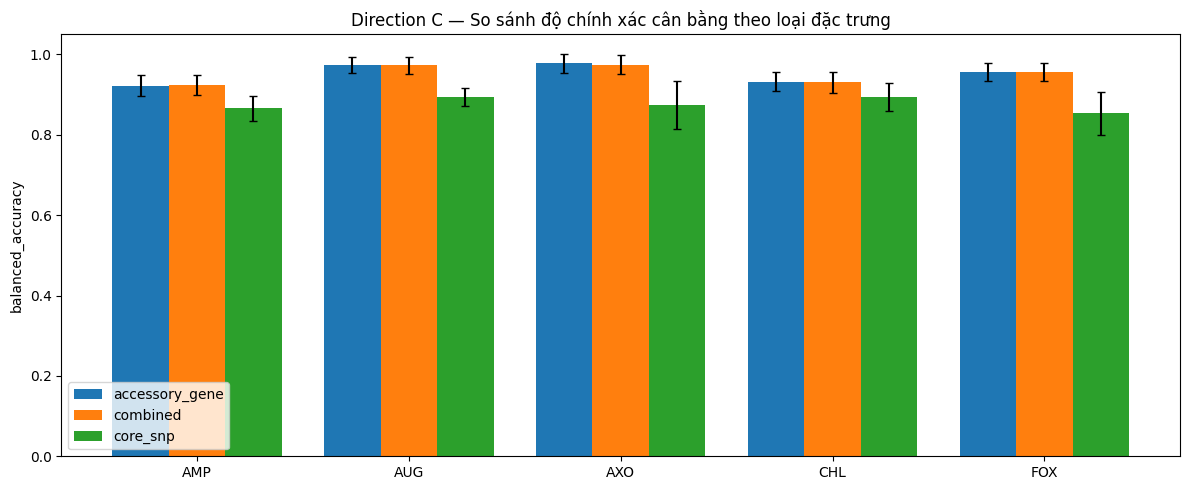

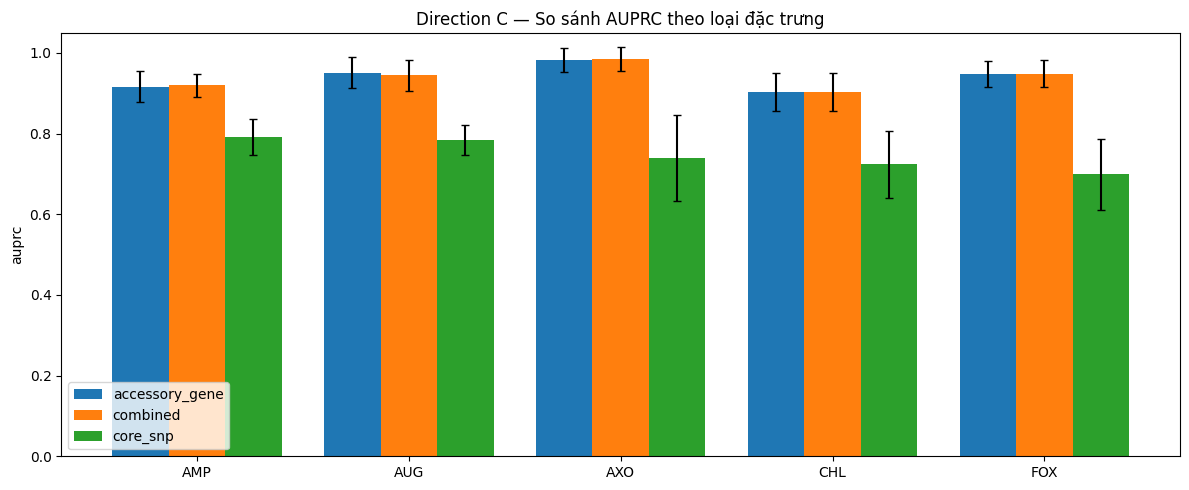

In [13]:
def plot_metric_bar(summary_df, metric_mean, metric_std, title, out_path):
    reps = list(summary_df["representation"].unique())
    drugs = DRUGS

    x = np.arange(len(drugs))
    width = 0.8 / max(len(reps), 1)

    plt.figure(figsize=(12, 5))

    for i, rep in enumerate(reps):
        values = []
        errors = []
        for drug in drugs:
            sub = summary_df[(summary_df["drug"] == drug) & (summary_df["representation"] == rep)]
            if len(sub) == 0:
                values.append(np.nan)
                errors.append(0)
            else:
                values.append(float(sub[metric_mean].iloc[0]))
                errors.append(float(sub[metric_std].iloc[0]))
        plt.bar(x + i*width - (len(reps)-1)*width/2, values, width, yerr=errors, capsize=3, label=rep)

    plt.xticks(x, drugs)
    plt.ylim(0, 1.05)
    plt.ylabel(metric_mean.replace("_mean", ""))
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()


plot_metric_bar(
    direction_C_summary,
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "Direction C — So sánh độ chính xác cân bằng theo loại đặc trưng",
    OUTPUT_DIR / "direction_C_balanced_accuracy_by_representation.png"
)

plot_metric_bar(
    direction_C_summary,
    "auprc_mean",
    "auprc_std",
    "Direction C — So sánh AUPRC theo loại đặc trưng",
    OUTPUT_DIR / "direction_C_auprc_by_representation.png"
)

## 13. Phân tích loại đặc trưng thắng nhiều nhất

In [14]:
win_counts_bacc = best_by_bacc["representation"].value_counts().rename_axis("representation").reset_index(name="wins_by_balanced_accuracy")
win_counts_auprc = best_by_auprc["representation"].value_counts().rename_axis("representation").reset_index(name="wins_by_auprc")

win_table = pd.merge(win_counts_bacc, win_counts_auprc, on="representation", how="outer").fillna(0)
display(win_table)
win_table.to_csv(OUTPUT_DIR / "direction_C_representation_win_counts.csv", index=False)

print("Số lần mỗi loại đặc trưng đứng đầu theo từng metric:")
display(win_table)

,representation,wins_by_balanced_accuracy,wins_by_auprc
0,accessory_gene,4,2
1,combined,1,3


Số lần mỗi loại đặc trưng đứng đầu theo từng metric:


,representation,wins_by_balanced_accuracy,wins_by_auprc
0,accessory_gene,4,2
1,combined,1,3


## 14. Đặc trưng được chọn ổn định theo từng representation

In [15]:
stable_rows = []

for drug, rep_counters in all_selected_counters.items():
    for rep_name, counter in rep_counters.items():
        total = N_REPEATS
        for feature, count in counter.most_common(30):
            stable_rows.append({
                "drug": drug,
                "representation": rep_name,
                "feature": feature,
                "selected_count": count,
                "selected_frequency": count / total,
            })

stable_features_df = pd.DataFrame(stable_rows)
display(stable_features_df.head(50))

stable_features_df.to_csv(OUTPUT_DIR / "direction_C_top_stable_features_by_representation.csv", index=False)

max_freq = stable_features_df["selected_frequency"].max() if len(stable_features_df) else np.nan
print("Tần suất lớn nhất:", max_freq)
if pd.notna(max_freq) and max_freq > 1.0:
    print("CẢNH BÁO: tần suất > 1, cần kiểm tra bộ đếm.")
else:
    print("OK: tần suất nằm trong khoảng 0–1.")

,drug,representation,feature,selected_count,selected_frequency
0,AMP,accessory_gene,group_3068,10,1.0
1,AMP,accessory_gene,CJW30_15375,10,1.0
2,AMP,accessory_gene,HF382_002470,10,1.0
3,AMP,accessory_gene,C0692_19640,10,1.0
4,AMP,accessory_gene,GXH02_05140,10,1.0
5,AMP,accessory_gene,FMQ12_17615,10,1.0
6,AMP,accessory_gene,DSP25_11545,10,1.0
7,AMP,accessory_gene,K1191_004890,10,1.0
8,AMP,accessory_gene,C3T99_20030,10,1.0
9,AMP,accessory_gene,FMQ12_17650,10,1.0


Tần suất lớn nhất: 1.0
OK: tần suất nằm trong khoảng 0–1.


## 15. Kết luận

In [16]:
lines = []
lines.append("# Kết luận tự động — Direction C")
lines.append("")
lines.append("## Mục tiêu")
lines.append("So sánh ba nhóm đặc trưng: gen phụ, biến thể lõi và kết hợp hai nhóm, nhằm xem loại tín hiệu hệ gen nào dự đoán kháng kháng sinh tốt hơn.")
lines.append("")
lines.append("## Thống kê dữ liệu")
for _, row in data_stats_df.iterrows():
    lines.append(f"- {row['drug']}: {int(row['n_samples'])} mẫu, {int(row['n_resistant'])} mẫu kháng ({row['resistant_rate']*100:.1f}%).")
lines.append("")
lines.append("## Kết quả tốt nhất theo độ chính xác cân bằng")
for _, row in best_by_bacc.iterrows():
    lines.append(
        f"- {row['drug']}: tốt nhất là {row['representation']}, "
        f"balanced accuracy = {row['balanced_accuracy_mean']:.3f} ± {row['balanced_accuracy_std']:.3f}, "
        f"AUPRC = {row['auprc_mean']:.3f} ± {row['auprc_std']:.3f}."
    )
lines.append("")
lines.append("## Kết quả tốt nhất theo AUPRC")
for _, row in best_by_auprc.iterrows():
    lines.append(
        f"- {row['drug']}: tốt nhất là {row['representation']}, "
        f"balanced accuracy = {row['balanced_accuracy_mean']:.3f} ± {row['balanced_accuracy_std']:.3f}, "
        f"AUPRC = {row['auprc_mean']:.3f} ± {row['auprc_std']:.3f}."
    )
lines.append("")
lines.append("## Diễn giải")
if X_core_snp is None:
    lines.append("- Notebook chưa đọc được ma trận biến thể lõi, nên Direction C chưa hoàn chỉnh. Kết quả hiện tại chỉ dùng gen phụ.")
else:
    if len(win_table):
        max_bacc_rep = win_table.sort_values("wins_by_balanced_accuracy", ascending=False).iloc[0]["representation"]
        max_auprc_rep = win_table.sort_values("wins_by_auprc", ascending=False).iloc[0]["representation"]
        lines.append(f"- Theo độ chính xác cân bằng, nhóm thắng nhiều nhất là: {max_bacc_rep}.")
        lines.append(f"- Theo AUPRC, nhóm thắng nhiều nhất là: {max_auprc_rep}.")
    lines.append("- Nếu gen phụ thắng nhiều hơn, điều này gợi ý tín hiệu kháng thuốc trong bộ dữ liệu nằm nhiều ở hệ gen phụ, có thể liên quan plasmid, gen di động hoặc gen kháng thuốc.")
    lines.append("- Nếu biến thể lõi thắng nhiều hơn, điều này gợi ý tín hiệu nằm nhiều ở các biến đổi nhỏ trong phần gen chung.")
    lines.append("- Nếu kết hợp thắng, điều này cho thấy hai loại tín hiệu có thể bổ sung cho nhau.")
lines.append("")
lines.append("## Gợi ý bước tiếp theo")
lines.append("- Nếu Direction C cho thấy gen phụ tốt hơn rõ, nên tập trung diễn giải sinh học các gen phụ ổn định.")
lines.append("- Nếu kết hợp tốt hơn, có thể phát triển mô hình tích hợp hai nguồn đặc trưng.")
lines.append("- Nếu core SNP không đọc được, cần kiểm tra lại file coreSNP.rar hoặc dùng bảng core SNP từ phụ lục/kho dữ liệu khác.")

conclusion_text = "\n".join(lines)
print(conclusion_text)

with open(OUTPUT_DIR / "AUTO_CONCLUSION_DIRECTION_C.md", "w", encoding="utf-8") as f:
    f.write(conclusion_text)

# Kết luận tự động — Direction C

## Mục tiêu
So sánh ba nhóm đặc trưng: gen phụ, biến thể lõi và kết hợp hai nhóm, nhằm xem loại tín hiệu hệ gen nào dự đoán kháng kháng sinh tốt hơn.

## Thống kê dữ liệu
- AMP: 1167 mẫu, 199 mẫu kháng (17.1%).
- AUG: 1167 mẫu, 139 mẫu kháng (11.9%).
- AXO: 1167 mẫu, 71 mẫu kháng (6.1%).
- CHL: 1167 mẫu, 126 mẫu kháng (10.8%).
- FOX: 1167 mẫu, 71 mẫu kháng (6.1%).

## Kết quả tốt nhất theo độ chính xác cân bằng
- AMP: tốt nhất là combined, balanced accuracy = 0.924 ± 0.025, AUPRC = 0.920 ± 0.029.
- AUG: tốt nhất là accessory_gene, balanced accuracy = 0.974 ± 0.020, AUPRC = 0.951 ± 0.039.
- AXO: tốt nhất là accessory_gene, balanced accuracy = 0.978 ± 0.024, AUPRC = 0.984 ± 0.030.
- CHL: tốt nhất là accessory_gene, balanced accuracy = 0.932 ± 0.024, AUPRC = 0.903 ± 0.048.
- FOX: tốt nhất là accessory_gene, balanced accuracy = 0.956 ± 0.023, AUPRC = 0.949 ± 0.033.

## Kết quả tốt nhất theo AUPRC
- AMP: tốt nhất là combined, balanced accuracy = 0.924 ± 0.0

## 16. zip

In [17]:
zip_path = BASE_DIR / "salmonella_direction_C_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)

print("Đã nén kết quả tại:", zip_path)
print("Nếu muốn tải về máy:")
print("from google.colab import files")
print(f"files.download('{zip_path}')")

Đã nén kết quả tại: /content/salmonella_direction_C/salmonella_direction_C_outputs.zip
Nếu muốn tải về máy:
from google.colab import files
files.download('/content/salmonella_direction_C/salmonella_direction_C_outputs.zip')
